Project #5: Video Stitching and Processing 

## CS445: Computational Photography

### Setup


In [1]:
import os
os.getcwd()

'/Users/kibaekim/Desktop/CS 445 Comp-Photography/MP5/cs445_proj5_starter/mp5'

In [2]:
# modify to where you store your project data including utils
datadir = "/Users/kibaekim/Desktop/CS 445 Comp-Photography/MP5/cs445_proj5_starter/mp5/" 

utilfn = datadir + "utils.py"
!cp "$utilfn" .
imagesfn = datadir + "images"
!cp -r "$imagesfn" .

cp: ./utils.py and /Users/kibaekim/Desktop/CS 445 Comp-Photography/MP5/cs445_proj5_starter/mp5/utils.py are identical (not copied).
cp: ./images and /Users/kibaekim/Desktop/CS 445 Comp-Photography/MP5/cs445_proj5_starter/mp5/images are identical (not copied).


In [3]:
import ffmpeg
import cv2
import numpy as np
import os
from numpy.linalg import svd, inv
import utils
%matplotlib inline
from matplotlib import pyplot as plt

### Part I: Stitch two key frames 

#### This involves:
1. compute homography H between two frames; 
2. project each frame onto the same surface;
3. blend the surfaces.

Check that your homography is correct by plotting four points that form a square in frame 270 and their projections in each image.

In [4]:
def score_projection(pt1, pt2, threshold=5.0):
    dists = np.linalg.norm(pt1 - pt2, axis=0)
    inliers = dists < threshold
    score = np.sum(inliers)
    return score, inliers


In [5]:
def auto_homography(Ia, Ib, homography_func=None, normalization_func=None, niter=1000, threshold=5.0):
    '''
    Computes a homography that maps points from Ia to Ib using SIFT + RANSAC
    '''
    if Ia.dtype == 'float32' and Ib.dtype == 'float32':
        Ia = (Ia * 255).astype(np.uint8)
        Ib = (Ib * 255).astype(np.uint8)

    Ia_gray = cv2.cvtColor(Ia, cv2.COLOR_BGR2GRAY)
    Ib_gray = cv2.cvtColor(Ib, cv2.COLOR_BGR2GRAY)

    sift = cv2.xfeatures2d.SIFT_create()
    kp_a, des_a = sift.detectAndCompute(Ia_gray, None)
    kp_b, des_b = sift.detectAndCompute(Ib_gray, None)

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des_a, des_b, k=2)

    good = [m for m, n in matches if m.distance < 0.75 * n.distance]
    numMatches = len(good)

    Xa = np.ones((3, numMatches))
    Xb = np.ones((3, numMatches))

    for idx, match in enumerate(good):
        Xa[:2, idx] = kp_a[match.queryIdx].pt
        Xb[:2, idx] = kp_b[match.trainIdx].pt

    best_score = 0
    n_to_sample = 4

    for _ in range(niter):
        subset = np.random.choice(numMatches, n_to_sample, replace=False)
        pts1 = Xa[:, subset]
        pts2 = Xb[:, subset]

        H_t = homography_func(pts1, pts2, normalization_func)
        Xb_proj = H_t @ Xa
        Xb_proj /= Xb_proj[2, :]

        score_t, inliers_t = score_projection(Xb[:2, :] / Xb[2, :], Xb_proj[:2, :], threshold)
        if score_t > best_score:
            best_score = score_t
            H = H_t
            in_idx = inliers_t

    print(f'best score: {best_score:.2f}')

    # Optional: re-estimate using all inliers
    Xa_inliers = Xa[:, in_idx]
    Xb_inliers = Xb[:, in_idx]
    H = homography_func(Xa_inliers, Xb_inliers, normalization_func)

    return H


In [6]:
def computeHomography(pts1, pts2, normalization_func=None):
    '''
    Compute homography that maps from pts1 to pts2 using DLT and SVD.

    Input:
        pts1, pts2: 3xN matrices (homogeneous coordinates)
        normalization_func: optional function that normalizes input points

    Output:
        H: 3x3 homography matrix, such that pts2 ≈ H * pts1
    '''

    # Normalize if normalization_func is provided
    if normalization_func is not None:
        pts1, T1 = normalization_func(pts1)
        pts2, T2 = normalization_func(pts2)
    else:
        T1 = T2 = np.eye(3)

    N = pts1.shape[1]
    A = []

    for i in range(N):
        x1, y1, w1 = pts1[:, i]
        x2, y2, w2 = pts2[:, i]

        # Skip if any point is at infinity
        if abs(w1) < 1e-8 or abs(w2) < 1e-8:
            continue

        # Normalize so last coordinate is 1
        x1 /= w1
        y1 /= w1
        x2 /= w2
        y2 /= w2

        # Construct two rows per correspondence
        A.append([0, 0, 0, -x1, -y1, -1, y2 * x1, y2 * y1, y2])
        A.append([x1, y1, 1, 0, 0, 0, -x2 * x1, -x2 * y1, -x2])

    A = np.array(A)

    # Solve Ah = 0 using SVD
    U, S, Vt = svd(A)
    h = Vt[-1, :]   # solution corresponds to smallest singular value
    H = h.reshape(3, 3)

    # Denormalize
    H = np.dot(np.dot(np.linalg.inv(T2), H), T1)

    # Normalize so that H[2,2] = 1
    H = H / H[2, 2]

    return H


In [7]:
# images location
im1 = './images/input/frames/f0270.jpg'
im2 = './images/input/frames/f0450.jpg'

# Load an color image in grayscale
im1 = cv2.imread(im1)
im2 = cv2.imread(im2)

H = auto_homography(im1,im2, computeHomography)
print(H/H.max()) 

# plot the frames here
box_pts = np.array([[300, 400, 400, 300, 300], [100, 100, 200, 200, 100], [1, 1, 1, 1, 1]])
plt.figure()
plt.imshow(im1[:,:,[2,1,0]])
plt.plot(box_pts[0,:], box_pts[1, :], 'r-')



best score: 220.00
[[ 1.00000000e+00  4.46094145e-02 -2.04453719e+02]
 [ 1.16333273e-02  9.47258844e-01 -1.46589464e+01]
 [ 3.66997470e-04  3.75036466e-05  8.19020914e-01]]


[ WARN:0@0.339] global shadow_sift.hpp:15 SIFT_create DEPRECATED: cv.xfeatures2d.SIFT_create() is deprecated due SIFT tranfer to the main repository. https://github.com/opencv/opencv/issues/16736


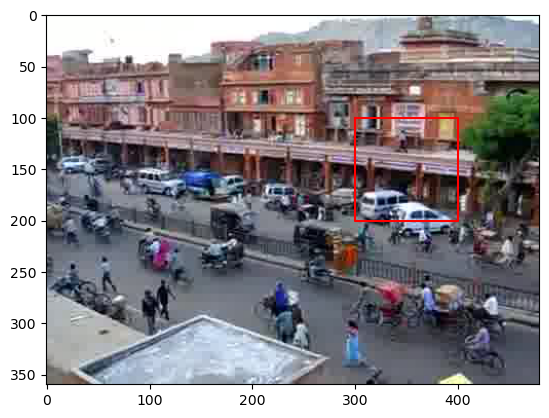

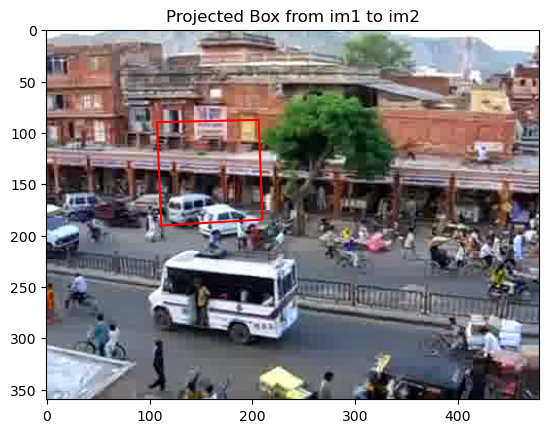

In [8]:
# TO DO: project points into im2 and display the projected lines on im2

projected_pts = H @ box_pts
projected_pts /= projected_pts[2, :]  # homogeneous normalization

plt.figure()
plt.imshow(im2[:, :, [2, 1, 0]])  # BGR → RGB
plt.plot(projected_pts[0, :], projected_pts[1, :], 'r-')
plt.title('Projected Box from im1 to im2')
plt.show()

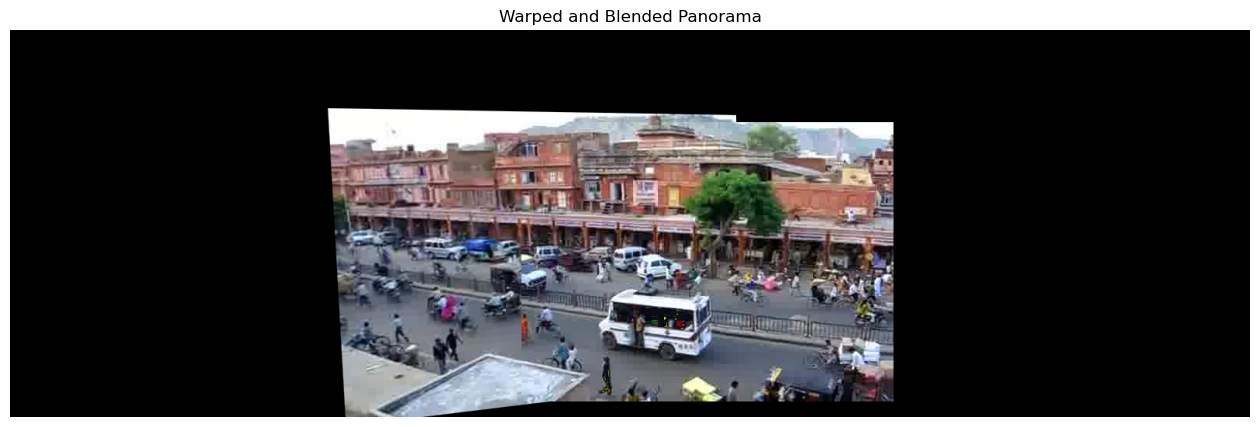

In [9]:
projectedWidth = 1600
projectedHeight = 500
Tr = np.array([[1, 0, 660], 
               [0, 1, 120], 
               [0, 0, 1]], dtype=np.float32)

# TO DO: warp and blend the two images
H_total = Tr @ H  
im1_warped = cv2.warpPerspective(im1, H_total, (projectedWidth, projectedHeight))
im2_warped = cv2.warpPerspective(im2, Tr, (projectedWidth, projectedHeight))
blended = utils.blendImages(im1_warped, im2_warped)
plt.figure(figsize=(16, 6))
plt.imshow(blended[:, :, [2, 1, 0]])  # BGR to RGB
plt.title('Warped and Blended Panorama')
plt.axis('off')
plt.show()

### Part II: Panorama using five key frames

Produce a panorama by mapping five key frames [90, 270, 450, 630, 810] onto the same reference frame 450.  


best score: 220.00
best score: 213.00
best score: 257.00
best score: 150.00


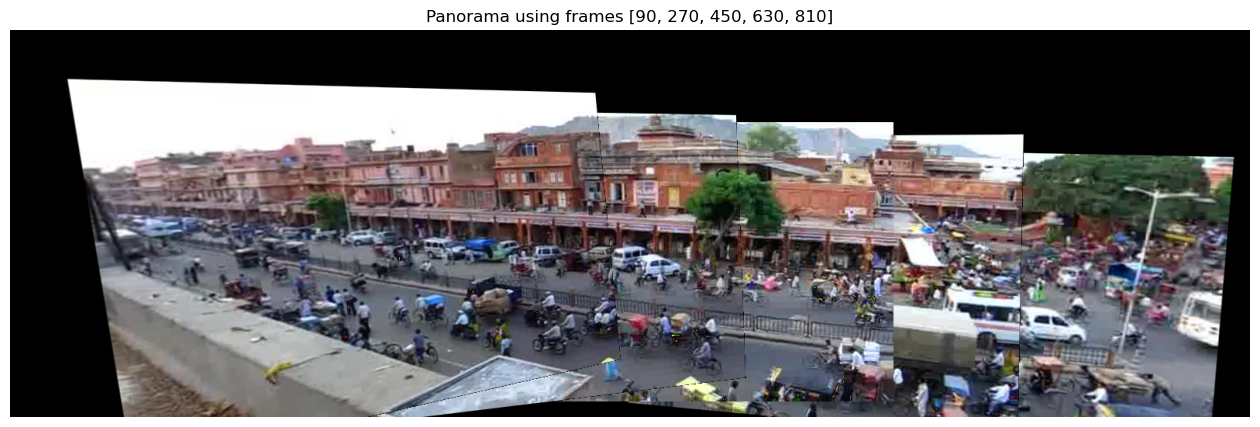

In [10]:
key_frames_idx = np.array([90, 270, 450, 630, 810])-1

frames = np.zeros((len(key_frames_idx), im1.shape[0], im1.shape[1], im1.shape[2]),dtype='uint8')
for n in range(len(key_frames_idx)):
  frames[n] = cv2.imread("./images/input/frames/f0{num}.jpg".format(num=str(key_frames_idx[n]+1).zfill(3)))

# TO DO solution

projectedWidth = 1600
projectedHeight = 500
Tr = np.array([[1, 0, 660], [0, 1, 120], [0, 0, 1]], dtype=np.float64)

ref_idx = 2  # frames[2] = frame 450
H_to_450 = {}
H_to_450[450] = np.eye(3)

# frame 270 → 450
H_270_450 = auto_homography(frames[1], frames[2], computeHomography)
H_to_450[270] = H_270_450

# frame 630 → 450
H_630_450 = auto_homography(frames[3], frames[2], computeHomography)
H_to_450[630] = H_630_450

# frame 90 → 270 → 450
H_90_270 = auto_homography(frames[0], frames[1], computeHomography)
H_to_450[90] = H_270_450 @ H_90_270

# frame 810 → 630 → 450
H_810_630 = auto_homography(frames[4], frames[3], computeHomography)
H_to_450[810] = H_630_450 @ H_810_630

# Panorama
panorama = np.zeros((projectedHeight, projectedWidth, 3), dtype=np.uint8)

for i, idx in enumerate([90, 270, 450, 630, 810]):
    Hi = Tr @ H_to_450[idx]
    warped = cv2.warpPerspective(frames[i], Hi, (projectedWidth, projectedHeight))
    panorama = utils.blendImages(warped, panorama)

plt.figure(figsize=(16, 6))
plt.imshow(panorama[:, :, [2, 1, 0]])  # BGR to RGB
plt.title("Panorama using frames [90, 270, 450, 630, 810]")
plt.axis("off")
plt.show()


### Part 3: Map the video to the reference plane

Project each frame onto the reference frame (using same size panorama) to create a video that shows the portion of the panorama revealed by each frame

In [11]:
import cv2, os, numpy as np, utils

# ---------- 0. load JPG frames ----------
dir_frames = 'images/input/frames'
fnames = sorted([os.path.join(dir_frames,f) for f in os.listdir(dir_frames)
                 if f.endswith('.jpg')],
                 key=lambda f: int(''.join(filter(str.isdigit, f))))
frames = np.stack([cv2.imread(f) for f in fnames], axis=0)    # (T,H,W,C)
T, H0, W0, _ = frames.shape

# ---------- 1. key-frame  ----------
keys     = {90:89, 270:269, 450:449, 630:629, 810:809}   # 1-based → 0-based
ref_kf   = 450                                            # 기준 프레임 = 450
Tr_local = np.array([[1,0,660],[0,1,120],[0,0,1]],float)  # starter code translation
H_to_ref = {ref_kf: np.eye(3)}

# ---------- 2. key-frame → ref Homography (high-RANSAC) ----------
H_to_ref[270] = auto_homography(frames[keys[270]], frames[keys[450]],
                                computeHomography, niter=3000, threshold=3.)
H_to_ref[630] = auto_homography(frames[keys[630]], frames[keys[450]],
                                computeHomography, niter=3000, threshold=3.)
H_to_ref[ 90] = H_to_ref[270] @ auto_homography(frames[keys[90]], frames[keys[270]],
                                computeHomography, niter=3000, threshold=3.)
H_to_ref[810] = H_to_ref[630] @ auto_homography(frames[keys[810]], frames[keys[630]],
                                computeHomography, niter=3000, threshold=3.)

def nearest_kf(i):           
    return min(keys, key=lambda k: abs((i+1)-k))

# ---------- 3. bbox, corner-warp ----------
def warp_corners(H, h, w):
    C = np.array([[0,w,w,0],[0,0,h,h],[1,1,1,1]])
    P = H@C;  P/=P[2];  return P[:2]                 # 2×4

H_curr = {}
pts_all = []
for i in range(T):
    k = nearest_kf(i)
    Hck = auto_homography(frames[i], frames[keys[k]],
                          computeHomography, niter=1500, threshold=4.)
    H_curr[i] = Hck
    H_tmp = Tr_local @ (H_to_ref[k] @ Hck)
    pts_all.append( warp_corners(H_tmp, H0, W0) )

pts_all = np.hstack(pts_all)
xmin,xmax = np.floor(pts_all[0].min()), np.ceil(pts_all[0].max())
ymin,ymax = np.floor(pts_all[1].min()), np.ceil(pts_all[1].max())
W_big, H_big = int(xmax-xmin), int(ymax-ymin)

T_global = np.array([[1,0,-xmin],[0,1,-ymin],[0,0,1]],float)

# ---------- 4. all frame warp ----------
warped = np.zeros((T, H_big, W_big, 3), np.uint8)
valid  = np.zeros(T,bool)

for i in range(T):
    k  = nearest_kf(i)
    Ht = T_global @ (Tr_local @ (H_to_ref[k] @ H_curr[i]))
    w  = cv2.warpPerspective(frames[i], Ht, (W_big, H_big))
    if w.mean(): warped[i], valid[i] = w, True

# ---------- 5. video storage ----------
utils.vidwrite_from_numpy('output_projected_video.mp4',
                          warped[valid], vcodec='mpeg4')
print('Part 3: output_projected_video.mp4 completed')


best score: 214.00
best score: 211.00
best score: 256.00
best score: 149.00
best score: 429.00
best score: 429.00
best score: 453.00
best score: 440.00
best score: 459.00
best score: 449.00
best score: 481.00
best score: 458.00
best score: 478.00
best score: 491.00
best score: 490.00
best score: 482.00
best score: 492.00
best score: 479.00
best score: 509.00
best score: 505.00
best score: 517.00
best score: 508.00
best score: 492.00
best score: 495.00
best score: 479.00
best score: 493.00
best score: 504.00
best score: 493.00
best score: 517.00
best score: 499.00
best score: 498.00
best score: 525.00
best score: 523.00
best score: 506.00
best score: 519.00
best score: 520.00
best score: 533.00
best score: 539.00
best score: 538.00
best score: 546.00
best score: 541.00
best score: 529.00
best score: 522.00
best score: 551.00
best score: 551.00
best score: 551.00
best score: 536.00
best score: 540.00
best score: 544.00
best score: 519.00
best score: 566.00
best score: 554.00
best score: 

best score: 450.00
best score: 439.00
best score: 410.00
best score: 441.00
best score: 462.00
best score: 426.00
best score: 449.00
best score: 487.00
best score: 493.00
best score: 483.00
best score: 456.00
best score: 446.00
best score: 502.00
best score: 528.00
best score: 484.00
best score: 521.00
best score: 536.00
best score: 534.00
best score: 548.00
best score: 594.00
best score: 687.00
best score: 929.00
best score: 2808.00
best score: 672.00
best score: 597.00
best score: 523.00
best score: 507.00
best score: 446.00
best score: 439.00
best score: 413.00
best score: 420.00
best score: 416.00
best score: 415.00
best score: 486.00
best score: 465.00
best score: 480.00
best score: 471.00
best score: 430.00
best score: 404.00
best score: 410.00
best score: 395.00
best score: 416.00
best score: 358.00
best score: 388.00
best score: 380.00
best score: 415.00
best score: 422.00
best score: 393.00
best score: 366.00
best score: 363.00
best score: 381.00
best score: 363.00
best score:

/var/folders/ds/vpyqnk654kzcxcg77ckyj1bh0000gn/T/ipykernel_69617/720198034.py:39: RuntimeWarning: divide by zero encountered in divide
  Xb_proj /= Xb_proj[2, :]
/var/folders/ds/vpyqnk654kzcxcg77ckyj1bh0000gn/T/ipykernel_69617/720198034.py:39: RuntimeWarning: invalid value encountered in divide
  Xb_proj /= Xb_proj[2, :]


best score: 227.00
best score: 236.00
best score: 231.00
best score: 223.00
best score: 239.00
best score: 235.00
best score: 237.00
best score: 224.00
best score: 224.00
best score: 222.00
best score: 232.00
best score: 223.00
best score: 212.00
best score: 214.00
best score: 206.00
best score: 223.00
best score: 259.00
best score: 238.00
best score: 241.00
best score: 250.00
best score: 246.00
best score: 227.00
best score: 269.00
best score: 268.00
best score: 255.00
best score: 269.00
best score: 264.00
best score: 266.00
best score: 272.00
best score: 288.00
best score: 230.00
best score: 280.00
best score: 276.00
best score: 260.00
best score: 252.00
best score: 241.00
best score: 261.00
best score: 277.00
best score: 282.00
best score: 317.00
best score: 293.00
best score: 266.00
best score: 262.00
best score: 283.00
best score: 250.00
best score: 267.00
best score: 229.00
best score: 255.00
best score: 296.00
best score: 249.00
best score: 263.00
best score: 283.00
best score: 

ffmpeg version 6.1.1 Copyright (c) 2000-2023 the FFmpeg developers
  built with clang version 14.0.6
  configuration: --prefix=/Users/kibaekim/anaconda3 --cc=arm64-apple-darwin20.0.0-clang --ar=arm64-apple-darwin20.0.0-ar --nm=arm64-apple-darwin20.0.0-nm --ranlib=arm64-apple-darwin20.0.0-ranlib --strip=arm64-apple-darwin20.0.0-strip --disable-doc --enable-swresample --enable-swscale --enable-openssl --enable-libxml2 --enable-libtheora --enable-demuxer=dash --enable-postproc --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libdav1d --enable-zlib --enable-libaom --enable-pic --enable-shared --disable-static --disable-gpl --enable-version3 --disable-sdl2 --enable-libopenh264 --enable-libopus --enable-libmp3lame --enable-libopenjpeg --enable-libvorbis --enable-pthreads --enable-libtesseract --enable-libvpx --enable-librsvg
  libavutil      58. 29.100 / 58. 29.100
  libavcodec     60. 31.102 / 60. 31.102
  libavformat    60. 16.100 / 60. 16

Part 3: output_projected_video.mp4 completed


[out#0/mp4 @ 0x600002b100c0] video:3238kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.169180%
frame= 1080 fps=516 q=31.0 Lsize=    3243kB time=00:00:35.96 bitrate= 738.7kbits/s dup=180 drop=0 speed=17.2x    


### Part 4: Create background panorama

Create a background panorama based on the result from Part 3.


/Users/kibaekim/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


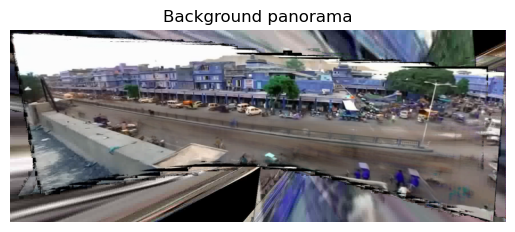

Part 4: background_panorama.png saved


In [12]:

# ---------- 0. video reopen ----------
cap = cv2.VideoCapture('output_projected_video.mp4')
if not cap.isOpened():
    raise IOError('failed to open output_projected_video.mp4')

frames = []
while True:
    ret,f = cap.read()
    if not ret: break
    frames.append(f)
cap.release()

video = np.stack(frames,axis=0).astype(np.float32)  # (T,H,W,3)

# ---------- 1. (0,0,0) masking ----------
mask_black = video.mean(axis=3) == 0        # True  ⇢ invalid
video[mask_black] = np.nan                  # NaN 

# ---------- 2. time axis nan-median → background ----------
background = np.nanmedian(video, axis=0)
background = np.nan_to_num(background).astype(np.uint8)

cv2.imwrite('background_panorama.png', background)
plt.imshow(background[...,::-1]); plt.axis('off')
plt.title('Background panorama'); plt.show()
print('Part 4: background_panorama.png saved')


### Part 5: Create background movie

Generate a movie that looks like the input movie but shows only background pixels. For each frame of the movie, you need to estimate a projection from the panorama to that frame. Your solution can use the background image you created in Part 4 and the per-frame homographies you created in Part 3. 


All frames populated with background.


ffmpeg version 6.1.1 Copyright (c) 2000-2023 the FFmpeg developers
  built with clang version 14.0.6
  configuration: --prefix=/Users/kibaekim/anaconda3 --cc=arm64-apple-darwin20.0.0-clang --ar=arm64-apple-darwin20.0.0-ar --nm=arm64-apple-darwin20.0.0-nm --ranlib=arm64-apple-darwin20.0.0-ranlib --strip=arm64-apple-darwin20.0.0-strip --disable-doc --enable-swresample --enable-swscale --enable-openssl --enable-libxml2 --enable-libtheora --enable-demuxer=dash --enable-postproc --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libdav1d --enable-zlib --enable-libaom --enable-pic --enable-shared --disable-static --disable-gpl --enable-version3 --disable-sdl2 --enable-libopenh264 --enable-libopus --enable-libmp3lame --enable-libopenjpeg --enable-libvorbis --enable-pthreads --enable-libtesseract --enable-libvpx --enable-librsvg
  libavutil      58. 29.100 / 58. 29.100
  libavcodec     60. 31.102 / 60. 31.102
  libavformat    60. 16.100 / 60. 16

✅  background_movie.mp4 generated


[out#0/mp4 @ 0x6000037f40c0] video:1118kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.487994%
frame= 1080 fps=0.0 q=31.0 Lsize=    1124kB time=00:00:35.96 bitrate= 256.0kbits/s dup=180 drop=0 speed= 100x    


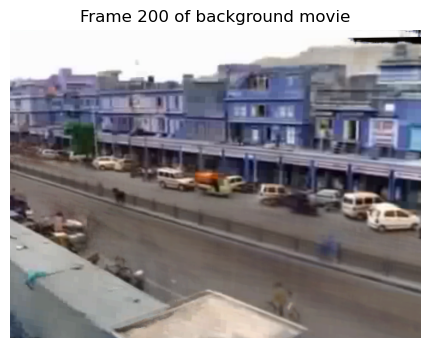

Frame 200 saved as frame200_background.png


In [18]:

# ------------------------------------------------------------------
# 0. Reload / confirm prerequisite data ----------------------------
# ------------------------------------------------------------------
background = cv2.imread('background_panorama.png')           # from Part 4
assert background is not None, "background_panorama.png not found"

# original frame array `orig_frames` was loaded at the top of Part 3:
#    orig_frames.shape == (T, H0, W0, 3)
orig_frames = frames        # keep the same variable name for clarity
T, H0, W0, _ = orig_frames.shape

# dictionaries & functions from Part 3 must still be in scope:
#   nearest_kf(i),  H_curr[i],  H_to_ref,  Tr_local,  T_global

# ------------------------------------------------------------------
# 1. Warp background panorama back into every original frame -------
# ------------------------------------------------------------------
background_movie = np.zeros_like(orig_frames)

for i in range(T):
    kf_num   = nearest_kf(i)                                  # closest key-frame
    H_total  = T_global @ (Tr_local @ (H_to_ref[kf_num]       # frame → panorama
                                       @ H_curr[i]))
    H_inv    = np.linalg.inv(H_total)                         # panorama → frame

    # project the panorama into the original frame canvas
    bg_warp  = cv2.warpPerspective(background, H_inv, (W0, H0))
    background_movie[i] = bg_warp

print("All frames populated with background.")

# ------------------------------------------------------------------
# 2. Encode the background-only video ------------------------------
# ------------------------------------------------------------------
utils.vidwrite_from_numpy('background_movie.mp4',
                          background_movie, framerate=30, vcodec='mpeg4')
print("✅  background_movie.mp4 generated")

# ------------------------------------------------------------------
# 3. Display & save frame 200 (index 199) --------------------------
# ------------------------------------------------------------------
frame_200 = background_movie[199]            # 0-based index
cv2.imwrite('frame200_background.png', frame_200)

plt.figure(figsize=(10,4))
plt.imshow(frame_200[..., ::-1])             # BGR → RGB
plt.axis('off');  plt.title('Frame 200 of background movie')
plt.show()
print("Frame 200 saved as frame200_background.png")


### Part 6: Create foreground movie

In the background video, moving objects are removed. In each frame, those pixels that are different enough than the background color are considered foreground. For each frame determine foreground pixels and generate a movie that emphasizes or includes only foreground pixels.

Foreground extraction done for all frames.


ffmpeg version 6.1.1 Copyright (c) 2000-2023 the FFmpeg developers
  built with clang version 14.0.6
  configuration: --prefix=/Users/kibaekim/anaconda3 --cc=arm64-apple-darwin20.0.0-clang --ar=arm64-apple-darwin20.0.0-ar --nm=arm64-apple-darwin20.0.0-nm --ranlib=arm64-apple-darwin20.0.0-ranlib --strip=arm64-apple-darwin20.0.0-strip --disable-doc --enable-swresample --enable-swscale --enable-openssl --enable-libxml2 --enable-libtheora --enable-demuxer=dash --enable-postproc --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libdav1d --enable-zlib --enable-libaom --enable-pic --enable-shared --disable-static --disable-gpl --enable-version3 --disable-sdl2 --enable-libopenh264 --enable-libopus --enable-libmp3lame --enable-libopenjpeg --enable-libvorbis --enable-pthreads --enable-libtesseract --enable-libvpx --enable-librsvg
  libavutil      58. 29.100 / 58. 29.100
  libavcodec     60. 31.102 / 60. 31.102
  libavformat    60. 16.100 / 60. 16

foreground_movie.mp4 generated


[out#0/mp4 @ 0x60000208c0c0] video:4606kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.118918%
frame= 1080 fps=0.0 q=31.0 Lsize=    4612kB time=00:00:35.96 bitrate=1050.4kbits/s dup=180 drop=0 speed=80.9x    


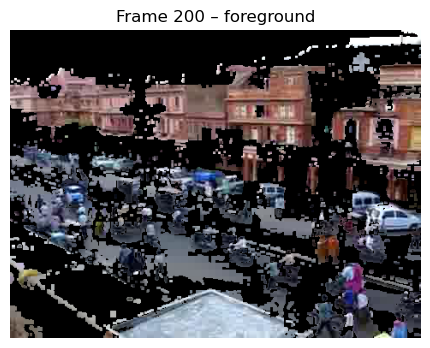

Frame 200 saved as frame200_foreground.png


In [19]:
# TO DO part 6
# ------------------------------------------------------------------
# 0.  Sanity-check array shapes ------------------------------------
# ------------------------------------------------------------------
assert orig_frames.shape == background_movie.shape, "frame stacks must match"
T, H, W, _ = orig_frames.shape

# ------------------------------------------------------------------
# 1.  Foreground mask per frame ------------------------------------
#     Difference metric:  Euclidean distance in RGB
#     Threshold can be tuned; here 30 (out of 255) works well.
# ------------------------------------------------------------------
THR = 30                       # pixel-wise color distance threshold
K   = 3                        # optional morphological kernel

fg_frames = np.zeros_like(orig_frames)   # will keep only foreground pix

for i in range(T):
    diff = np.linalg.norm(
            orig_frames[i].astype(np.int16) -
            background_movie[i].astype(np.int16), axis=2)
    
    mask = (diff > THR).astype(np.uint8)           # 1 = foreground
    # optional clean-up: remove isolated noise
    if K:
        kernel = np.ones((K, K), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    mask3 = np.repeat(mask[:, :, None], 3, axis=2) # 3-channel

    # Option A  — keep foreground, paint others black
    fg_frames[i] = orig_frames[i] * mask3
    
    # Option B — highlight foreground in red overlay (comment/uncomment)
    # fg_frames[i] = background_movie[i].copy()
    # fg_frames[i][mask == 1] = [0, 0, 255]         # red highlight (BGR)

print("Foreground extraction done for all frames.")

# ------------------------------------------------------------------
# 2.  Encode foreground-only movie ---------------------------------
# ------------------------------------------------------------------
utils.vidwrite_from_numpy('foreground_movie.mp4',
                          fg_frames, framerate=30, vcodec='mpeg4')
print("foreground_movie.mp4 generated")

# ------------------------------------------------------------------
# 3.  Display & save frame 200 (index 199) -------------------------
# ------------------------------------------------------------------
frame200_fg = fg_frames[199]
cv2.imwrite('frame200_foreground.png', frame200_fg)

plt.figure(figsize=(10,4))
plt.imshow(frame200_fg[..., ::-1])        # BGR ➜ RGB
plt.axis('off'); plt.title('Frame 200 – foreground')
plt.show()
print("Frame 200 saved as frame200_foreground.png")


## Bells and whistles